In [9]:
import numpy as np 
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

In [10]:
df = pd.read_csv("craigslist_vehicles.csv")

In [11]:
df.shape

(426880, 28)

In [12]:
df.isnull().sum()

Unnamed: 0           0
id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
removal_date        68
dtype: int64

In [13]:
df.columns

Index(['Unnamed: 0', 'id', 'url', 'region', 'region_url', 'price', 'year',
       'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer',
       'title_status', 'transmission', 'VIN', 'drive', 'size', 'type',
       'paint_color', 'image_url', 'description', 'county', 'state', 'lat',
       'long', 'posting_date', 'removal_date'],
      dtype='object')

In [14]:
df = df.drop("Unnamed: 0", axis=1)

In [15]:
df[df["price"] == 0]

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,type,paint_color,image_url,description,county,state,lat,long,posting_date,removal_date
13,7303347398,https://abilene.craigslist.org/ctd/d/abilene-p...,abilene,https://abilene.craigslist.org,0,2018.0,NaN,peterbilt 579,NaN,NaN,...,NaN,NaN,https://images.craigslist.org/01010_ksjVGjuoel...,"◄ PRICES STARTING AT $57,500 ($57,500 and up, ...",NaN,tx,32.444650,-99.725647,2021-04-07 00:00:00+00:00,2021-04-19 00:00:00+00:00
158,7316929445,https://abilene.craigslist.org/ctd/d/san-anton...,abilene,https://abilene.craigslist.org,0,2011.0,NaN,2016 F450-F750,NaN,NaN,...,NaN,NaN,https://images.craigslist.org/01515_eHdJeW15KY...,GO TO WWW.BUCKETTRUCKSALES.COM FOR PRICING AND...,NaN,tx,29.383820,-98.325577,2021-05-04 00:00:00+00:00,2021-05-13 00:00:00+00:00
159,7316891761,https://abilene.craigslist.org/ctd/d/snyder-pr...,abilene,https://abilene.craigslist.org,0,2020.0,dodge,durango r/t,good,8 cylinders,...,SUV,grey,https://images.craigslist.org/00606_hKJQ3Gz3Ry...,Pre-Owned 2020 Dodge Durango R/T With Navigati...,NaN,tx,32.745100,-100.917500,2021-05-04 00:00:00+00:00,2021-05-15 00:00:00+00:00
163,7309763443,https://abilene.craigslist.org/ctd/d/sweetwate...,abilene,https://abilene.craigslist.org,0,2011.0,kia,forte,NaN,NaN,...,sedan,white,https://images.craigslist.org/00t0t_abGaAavpAI...,Stanley Ford Sweetwater address: 603 Southw...,NaN,tx,32.447591,-100.408954,2021-04-20 00:00:00+00:00,2021-04-30 00:00:00+00:00
167,7316697721,https://abilene.craigslist.org/ctd/d/sweetwate...,abilene,https://abilene.craigslist.org,0,2014.0,ford,expedition,NaN,NaN,...,SUV,white,https://images.craigslist.org/01717_kwYH9W4SsY...,Stanley Ford Sweetwater address: 603 Southw...,NaN,tx,32.447591,-100.408954,2021-05-04 00:00:00+00:00,2021-05-19 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426385,7306717007,https://yuma.craigslist.org/ctd/d/tucson-diese...,yuma,https://yuma.craigslist.org,0,2013.0,ford,f450 lariat,NaN,NaN,...,NaN,NaN,https://images.craigslist.org/00X0X_2Ma2oIDyG0...,This is a loaded Lariat F450 and not a 350. Gr...,NaN,az,32.269100,-110.984500,2021-04-14 00:00:00+00:00,2021-04-29 00:00:00+00:00
426429,7310125533,https://yuma.craigslist.org/ctd/d/yuma-cars-fo...,yuma,https://yuma.craigslist.org,0,2011.0,hyundai,sonata,like new,NaN,...,NaN,NaN,https://images.craigslist.org/00202_bgwu5iJSyi...,Zippy Auto Sales provides a 100% clean & safe ...,NaN,az,32.701500,-114.642400,2021-04-21 00:00:00+00:00,2021-04-23 00:00:00+00:00
426657,7305635388,https://zanesville.craigslist.org/ctd/d/chilli...,zanesville / cambridge,https://zanesville.craigslist.org,0,2012.0,ford,f-250,NaN,NaN,...,NaN,NaN,https://images.craigslist.org/00M0M_74sFypoSIw...,!!!$$$TAX TIME IS HERE$$$!!! Put your tax retu...,NaN,oh,39.368154,-82.975784,2021-04-12 00:00:00+00:00,2021-04-22 00:00:00+00:00
426717,7315409843,https://zanesville.craigslist.org/ctd/d/lancas...,zanesville / cambridge,https://zanesville.craigslist.org,0,2012.0,ford,f-250,NaN,NaN,...,NaN,NaN,https://images.craigslist.org/00M0M_74sFypoSIw...,!!!$$$TAX TIME IS HERE$$$!!! Put your tax ret...,NaN,oh,39.743063,-82.638437,2021-05-01 00:00:00+00:00,2021-05-21 00:00:00+00:00


In [16]:
#Dropping adverts with price 0

df = df[df["price"] != 0]

In [17]:
df.shape

(393985, 27)

In [18]:
df[df["price"]<500]["description"]

253       2007 JEEP LIBERTY SPORT  Selling Dealer: Bucke...
265       2008 LINCOLN MKZ  Selling Dealer: Buckeye Auto...
266       2008 MERCURY SABLE LUXURY  Selling Dealer: Buc...
269       2008 TOYOTA PRIUS  Selling Dealer: Buckeye Aut...
275       2010 CHEVROLET HHR LS  Selling Dealer: Buckeye...
                                ...                        
426587    Don't let your credit hold you up! We've got p...
426588    Don't let your credit hold you up! We've got p...
426589    Don't let your credit hold you up! We've got p...
426590    Don't let your credit hold you up! We've got p...
426878    1986 Iroc Z28 , T-tops , 86,500 miles , has ne...
Name: description, Length: 9199, dtype: object

In [19]:
df[df["price"] < 500]["description"].str.contains(
    "dealer|VIN|Stock|down payment|finance|monthly",
    case=False,
    na=False
).mean()

np.float64(0.8134579845635395)

In [20]:
mask = (
    (df["price"] < 500) &
    df["description"].str.contains(
        "dealer|VIN|Stock|down payment|finance|monthly",
        case=False,
        na=False
    )
)

df = df[~mask]

In [21]:
df.shape

(386502, 27)

Exploratory analysis showed that 81% of sub-$500 listings contained dealership or financing-related language, suggesting that many prices represented promotional values rather than full transaction prices.

In [22]:
# fake price detection and cleaning

In [23]:
import pandas as pd
import re

#cleaning description column
df["description_clean"] = (
    df["description"]
    .fillna("")
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

#fake/spam advert words
finance_keywords = [
    "bad credit",
    "no credit",
    "credit approval",
    "payment plan",
    "payment plans",
    "monthly payment",
    "weekly payment",
    "bi-weekly payment",
    "down payment",
    "low down",
    "finance",
    "financing",
    "pre-approved",
    "pre approved",
    "fixed income",
    "repos",
    "repo",
    "everyone approved",
    "guaranteed approval",
    "get approved",
    "easy approval",
    "buy here pay here",
    "b.h.p.h",
    "lease here pay here"
]

finance_pattern = "|".join(map(re.escape, finance_keywords))

#financing language flag
df["has_finance_terms"] = df["description_clean"].str.contains(
    finance_pattern,
    regex=True,
    na=False
)

#spam payment pattern
df["has_payment_pattern"] = df["description_clean"].str.contains(
    r"\$\s?\d+\s*/\s*(month|mo|week)|monthly|weekly|down payment",
    regex=True,
    na=False
)

df["finance_signal"] = df["has_finance_terms"] | df["has_payment_pattern"]

#price validity rule
def price_validity_label(row):
    price = row["price"]
    finance_signal = row["finance_signal"]

    if price < 500 and finance_signal:
        return "invalid"
    elif price < 1000 and finance_signal:
        return "suspicious"
    elif price < 500:
        return "suspicious"
    else:
        return "valid"

df["price_validity"] = df.apply(price_validity_label, axis=1)

print("Price validity dağılımı:")
print(df["price_validity"].value_counts(dropna=False))
print()

print("Original shape:", df.shape)

df = df[df["price_validity"] == "valid"].copy()

print("Model shape   :", df.shape)
print()

#examples
pd.set_option("display.max_colwidth", None)
cols = ["price", "year", "manufacturer", "model", "price_validity", "description"]



C:\Users\HP\AppData\Local\Temp\ipykernel_27140\711100124.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_payment_pattern"] = df["description_clean"].str.contains(


Price validity dağılımı:
price_validity
valid         382111
suspicious      3818
invalid          573
Name: count, dtype: int64

Original shape: (386502, 32)
Model shape   : (382111, 32)



In [24]:
# price distribution
df["price"].describe(percentiles=[.90,.95,.97,.99,.995,.999])

count    3.821110e+05
mean     8.400009e+04
std      1.287615e+07
min      5.000000e+02
50%      1.599000e+04
90%      3.859000e+04
95%      4.559000e+04
97%      5.288000e+04
99%      6.899500e+04
99.5%    7.950000e+04
99.9%    1.249000e+05
max      3.736929e+09
Name: price, dtype: float64

In [25]:
#removing price outliers from df

df = df[df["price"] <= 80000]

In [26]:
df.describe()

,id,price,year,odometer,county,lat,long
count,3.804840e+05,380484.000000,379374.000000,3.784250e+05,0.0,377032.000000,377032.000000
mean,7.311459e+09,19113.966474,2010.939543,9.897374e+04,NaN,38.504322,-94.264303
std,4.478265e+06,13959.855097,9.585434,1.921031e+05,NaN,5.838259,18.060475
min,7.207408e+09,500.000000,1900.000000,0.000000e+00,NaN,-84.122245,-159.719900
25%,7.308075e+09,7900.000000,2008.000000,3.887400e+04,NaN,34.708828,-110.886900
50%,7.312562e+09,15977.000000,2013.000000,8.817500e+04,NaN,39.198327,-87.980000
75%,7.315240e+09,27990.000000,2017.000000,1.365650e+05,NaN,42.346455,-80.797875
max,7.317101e+09,80000.000000,2022.000000,1.000000e+07,NaN,82.390818,167.629911


In [27]:
df["year"].isnull().sum()

np.int64(1110)

In [28]:
df = df[df["year"] >= 2000]

In [29]:
df.describe()

,id,price,year,odometer,county,lat,long
count,3.553230e+05,355323.000000,355323.000000,3.533790e+05,0.0,352003.000000,352003.000000
mean,7.311428e+09,19566.984645,2012.787599,9.502905e+04,NaN,38.502066,-94.074883
std,4.392986e+06,13904.472151,5.053289,1.215097e+05,NaN,5.844308,18.030431
min,7.301583e+09,500.000000,2000.000000,0.000000e+00,NaN,-84.122245,-159.719900
25%,7.308028e+09,7999.000000,2009.000000,3.838700e+04,NaN,34.708828,-108.576627
50%,7.312438e+09,16495.000000,2014.000000,8.739600e+04,NaN,39.220900,-87.843300
75%,7.315194e+09,28000.000000,2017.000000,1.350175e+05,NaN,42.350399,-80.731900
max,7.317101e+09,80000.000000,2022.000000,1.000000e+07,NaN,82.252826,167.629911


In [30]:
df.shape

(355323, 32)

In [31]:
import matplotlib.pyplot as plt

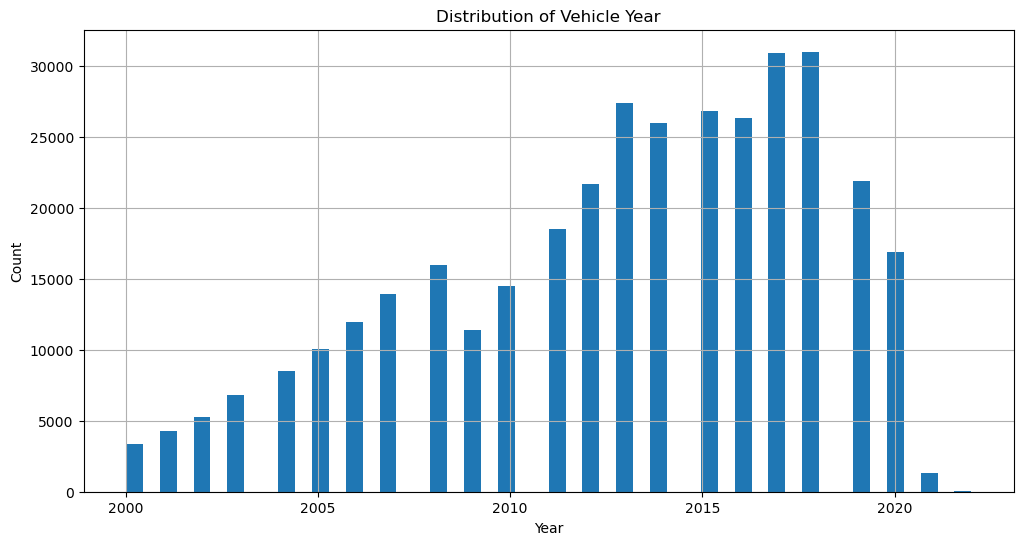

In [32]:
#year of vehicle distribution

plt.figure(figsize=(12, 6))
df["year"].dropna().hist(bins=50)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Distribution of Vehicle Year")
plt.show()

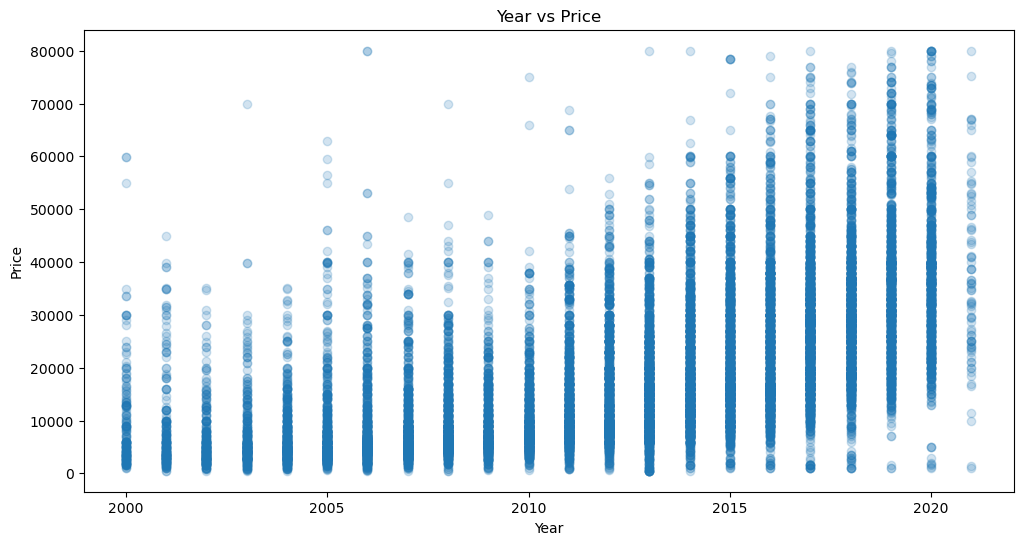

In [33]:
#Comparing year and price
sample_df = df[["year", "price"]].dropna().sample(20000, random_state=42)

plt.figure(figsize=(12, 6))
plt.scatter(sample_df["year"], sample_df["price"], alpha=0.2)
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Price")
plt.show()

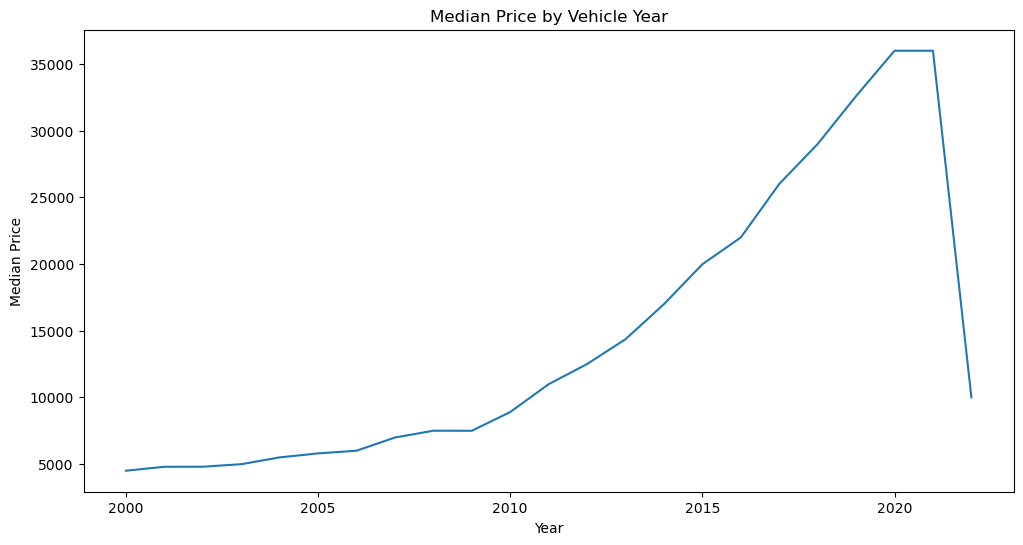

In [34]:
#median price of cars by year

median_price_by_year = (
    df.groupby("year")["price"]
    .median()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(median_price_by_year.index, median_price_by_year.values)
plt.xlabel("Year")
plt.ylabel("Median Price")
plt.title("Median Price by Vehicle Year")
plt.show()

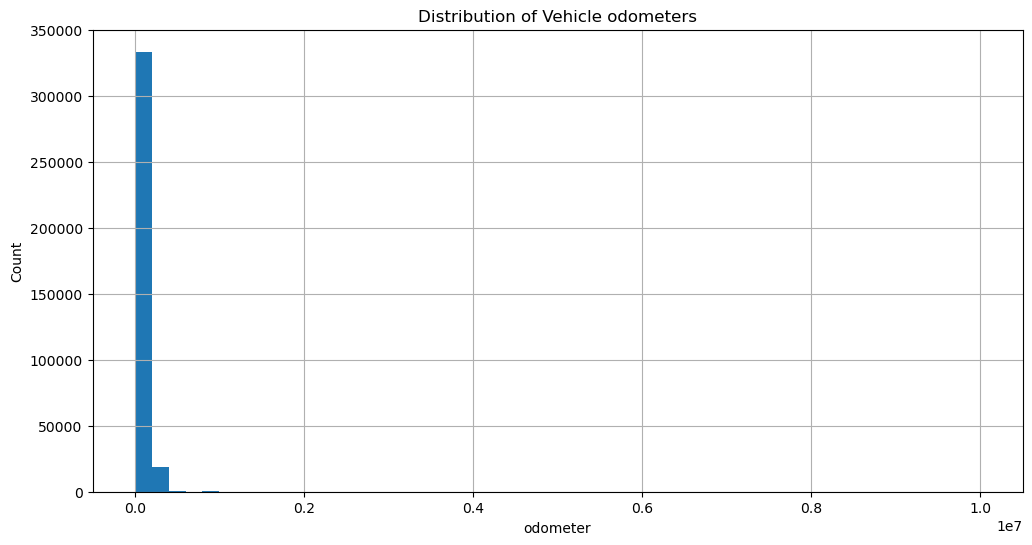

In [35]:
#odometer distribution

plt.figure(figsize=(12, 6))
df["odometer"].dropna().hist(bins=50)
plt.xlabel("odometer")
plt.ylabel("Count")
plt.title("Distribution of Vehicle odometers")
plt.show()

In [36]:
df["odometer"].describe(percentiles=[.90,.95,.97,.99,.995,.999])

count    3.533790e+05
mean     9.502905e+04
std      1.215097e+05
min      0.000000e+00
50%      8.739600e+04
90%      1.769100e+05
95%      2.020000e+05
97%      2.210000e+05
99%      2.660863e+05
99.5%    3.042947e+05
99.9%    9.859782e+05
max      1.000000e+07
Name: odometer, dtype: float64

In [37]:
df["odometer"].max()

10000000.0

In [38]:
#removing odometer outliers from df

df = df[df["odometer"] <= 300000]

In [39]:
df.shape

(351523, 32)

In [40]:
df.describe()

,id,price,year,odometer,county,lat,long
count,3.515230e+05,351523.000000,351523.000000,351523.000000,0.0,348209.000000,348209.000000
mean,7.311428e+09,19590.752085,2012.814473,91445.141103,NaN,38.511617,-94.021067
std,4.394881e+06,13894.279755,5.041783,61026.365722,NaN,5.844117,18.025435
min,7.301583e+09,500.000000,2000.000000,0.000000,NaN,-81.838232,-159.719900
25%,7.308026e+09,8000.000000,2009.000000,38094.000000,NaN,34.720000,-108.539000
50%,7.312438e+09,16500.000000,2014.000000,86986.000000,NaN,39.254962,-87.800000
75%,7.315200e+09,28200.000000,2017.000000,134249.000000,NaN,42.354200,-80.705220
max,7.317101e+09,80000.000000,2022.000000,300000.000000,NaN,82.252826,167.629911


In [41]:
df[df["odometer"] == 0].count()

id                     715
url                    715
region                 715
region_url             715
price                  715
year                   715
manufacturer           585
model                  710
condition              433
cylinders              461
fuel                   685
odometer               715
title_status           551
transmission           715
VIN                    641
drive                  439
size                   100
type                   540
paint_color            462
image_url              715
description            715
county                   0
state                  715
lat                    677
long                   677
posting_date           715
removal_date           715
description_clean      715
has_finance_terms      715
has_payment_pattern    715
finance_signal         715
price_validity         715
dtype: int64

In [42]:
zero_odo = df[df["odometer"] == 0]

In [43]:
zero_odo["year"].value_counts().sort_index()

year
2000.0     9
2001.0    16
2002.0    11
2003.0    18
2004.0    20
2005.0    16
2006.0    24
2007.0    20
2008.0    60
2009.0    23
2010.0    52
2011.0    62
2012.0    49
2013.0    30
2014.0    56
2015.0    58
2016.0    53
2017.0    45
2018.0    33
2019.0    11
2020.0    15
2021.0    34
Name: count, dtype: int64

In [44]:
df = df[df["odometer"] > 0]

In [45]:
df.describe()

,id,price,year,odometer,county,lat,long
count,3.508080e+05,350808.000000,350808.000000,350808.000000,0.0,347532.000000,347532.000000
mean,7.311427e+09,19601.575643,2012.816398,91631.520193,NaN,38.514787,-94.000291
std,4.394639e+06,13896.000874,5.041416,60948.581669,NaN,5.843566,18.018993
min,7.301583e+09,500.000000,2000.000000,1.000000,NaN,-81.838232,-159.719900
25%,7.308025e+09,8000.000000,2009.000000,38443.000000,NaN,34.728066,-108.539000
50%,7.312437e+09,16500.000000,2014.000000,87000.000000,NaN,39.254962,-87.770500
75%,7.315199e+09,28395.000000,2017.000000,134415.000000,NaN,42.354201,-80.695800
max,7.317101e+09,80000.000000,2022.000000,300000.000000,NaN,82.252826,167.629911


In [46]:
ten_odo = df[df["odometer"] <= 10]

In [47]:
ten_odo["year"].value_counts().sort_index()

year
2000.0     19
2001.0     16
2002.0     27
2003.0     42
2004.0     46
2005.0     69
2006.0     94
2007.0    116
2008.0     89
2009.0     64
2010.0     97
2011.0     79
2012.0     76
2013.0     89
2014.0     72
2015.0    144
2016.0     34
2017.0     72
2018.0     33
2019.0     41
2020.0    222
2021.0    327
2022.0     20
Name: count, dtype: int64

In [48]:
#removing less than 10 odometers before the year 2019

df = df[
    ~(
        (df["year"] <= 2019) &
        (df["odometer"] <= 10)
    )
].copy() 

In [49]:
df.shape

(349489, 32)

In [50]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date', 'removal_date', 'description_clean',
       'has_finance_terms', 'has_payment_pattern', 'finance_signal',
       'price_validity'],
      dtype='object')

In [51]:
df.isnull().sum()

id                          0
url                         0
region                      0
region_url                  0
price                       0
year                        0
manufacturer             9890
model                    2779
condition              132922
cylinders              145028
fuel                     2028
odometer                    0
title_status             5753
transmission             1427
VIN                    124273
drive                  105114
size                   253832
type                    70606
paint_color             98261
image_url                   0
description                 2
county                 349489
state                       0
lat                      3243
long                     3243
posting_date                0
removal_date                0
description_clean           0
has_finance_terms           0
has_payment_pattern         0
finance_signal              0
price_validity              0
dtype: int64

In [52]:
# handling null values for manufacturer

df = df.dropna(subset=["manufacturer"])

In [53]:
# handling null values for model

df = df.dropna(subset=["model"])

In [54]:
df.shape

(336820, 32)

In [55]:
df["condition"] = df["condition"].fillna("unknown")

In [56]:
df["type"] = df["type"].fillna("unknown")

In [57]:
df["fuel"] = df["fuel"].fillna("unknown")

In [58]:
df["title_status"] = df["title_status"].fillna("unknown")

In [59]:
df["transmission"] = df["transmission"].fillna("unknown")

In [60]:
df.isnull().sum()

id                          0
url                         0
region                      0
region_url                  0
price                       0
year                        0
manufacturer                0
model                       0
condition                   0
cylinders              138943
fuel                        0
odometer                    0
title_status                0
transmission                0
VIN                    117778
drive                  100503
size                   245299
type                        0
paint_color             93960
image_url                   0
description                 2
county                 336820
state                       0
lat                      3199
long                     3199
posting_date                0
removal_date                0
description_clean           0
has_finance_terms           0
has_payment_pattern         0
finance_signal              0
price_validity              0
dtype: int64

In [61]:
df["transmission"].value_counts()

transmission
automatic    263298
other         58130
manual        14009
unknown        1383
Name: count, dtype: int64

In [62]:
df["fuel"].value_counts()

fuel
gas         283764
other        25604
diesel       19426
hybrid        4645
unknown       1912
electric      1469
Name: count, dtype: int64

In [63]:
df.describe()

,id,price,year,odometer,county,lat,long
count,3.368200e+05,336820.000000,336820.000000,336820.000000,0.0,333621.000000,333621.000000
mean,7.311438e+09,19657.743151,2012.904887,91531.655585,NaN,38.520340,-94.067987
std,4.387359e+06,13802.608859,5.010224,60472.952279,NaN,5.852423,18.031088
min,7.301583e+09,500.000000,2000.000000,1.000000,NaN,-81.838232,-159.719900
25%,7.308036e+09,8323.000000,2010.000000,38664.500000,NaN,34.728066,-108.539000
50%,7.312458e+09,16598.000000,2014.000000,87000.000000,NaN,39.235300,-87.859000
75%,7.315204e+09,28405.250000,2017.000000,134000.000000,NaN,42.373383,-80.794700
max,7.317101e+09,80000.000000,2022.000000,300000.000000,NaN,82.252826,167.629911


In [64]:
df.shape

(336820, 32)

In [65]:
df["description"].head()

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [66]:
df = df.dropna(subset=["description"])

In [67]:
#cleaning description columns for trust score
def clean_for_trust(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)       
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.]+', ' ', text) 
    text = re.sub(r'\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}', ' ', text) 
    text = re.sub(r'\d{5}(?:-\d{4})?', ' ', text)     
    text = re.sub(r'[^\w\s!?.,-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["desc_trust_clean"] = df["description"].apply(clean_for_trust)

print("description values cleaned.")
print(df["desc_trust_clean"].head(2).values)

description values cleaned.
['4,500 cash 2002 bmw x5 8 cylinder 4.4l motor automatic transmission 184k miles leather seats cold ac and great heater this car runs great, has a new water pump! leather seat are in good condition. has some small issues with the interior. does have some small blemishes. this is a great car, come by and take it for a test drive! let s make a deal! call or text bmw stop by lnc auto sales 1842 n first st abilene tx'
 '4,500 cash 2002 bmw x5 8 cylinder 4.4l motor automatic transmission 184k miles leather seats cold ac and great heater this car runs great, has a new water pump! leather seat are in good condition. has some small issues with the interior. does have some small blemishes. this is a great car, come by and take it for a test drive! let s make a deal! call or text bmw stop by lnc auto sales 1842 n first st abilene tx']


In [81]:
#Asigning signal Lists 

#honest signals in descriptions
HONEST_SIGNALS = [
    "bring your mechanic",
    "as shown in pictures",
    "as shown in photos",
    "rips and tears",
    "rips or tears",
    "some issues",
    "minor issues",
    "small issues",
    "has some",
    "needs work",
    "recently replaced",
    "new water pump",
    "new tires",
    "new brakes",
    "just serviced",
    "oil change",
    "inspection done",
    "test drive",
    "carfax",
    "clean title",
    "one owner",
    "non smoker",
    "non-smoker",
    "asking price",
    "priced to sell",
]

#Suspicious signals (pressure tactics, disclaimers, spam)
SUSPICIOUS_SIGNALS = [
    "must sell",
    "won't last",
    "wont last",
    "don't miss",
    "dont miss",
    "act now",
    "today only",
    "limited time",
    "hurry",
    "as is",
    "as-is",
    "no warranty",
    "no return",
    "sold as is",
    "salvage",
    "flood",
    "flood damage",
    "rebuilt title",
    "mechanic special",
    "project car",
    "bad credit",
    "no credit",
    "buy here pay here",
    "everyone approved",
    "guaranteed approval",
    "call or text", 
    "stop by",
]

print(f"Number of Honesty Signals : {len(HONEST_SIGNALS)}")
print(f"Number of Suspicious Signals : {len(SUSPICIOUS_SIGNALS)}")

Number of Honesty Signals : 25
Number of Suspicious Signals : 27


In [82]:
#Repetitive word ratio. If high, it is spam. 
#It detects instances where the same word appears dozens of times.
def keyword_stuffing_score(text: str) -> float:
    words = text.split()
    if len(words) < 5:
        return 0.0
    unique_ratio = len(set(words)) / len(words)
    return round(1 - unique_ratio, 4) 

#Capitalization ratio. If high, aggressive marketing.
def caps_ratio(text: str) -> float:
    if len(text) == 0:
        return 0.0
    return sum(1 for c in text if c.isupper()) / len(text)

#Exclamation ratio
def exclamation_ratio(text: str) -> float:
    if len(text) == 0:
        return 0.0
    return text.count("!") / len(text)


#Word count. Too short or too long is suspicious.
def word_count(text: str) -> int:
    return len(text.split())

#Trust weight derived from the 'title_status' column
def title_trust_map(title_status: str) -> float:
    mapping = {
        "clean":      1.00,
        "lien":       0.55,
        "rebuilt":    0.45,
        "salvage":    0.15,
        "missing":    0.10,
        "parts only": 0.05,
        "unknown":    0.40, 
    }
    return mapping.get(str(title_status).lower().strip(), 0.40)

In [70]:
#Trust Score Function

def compute_trust_score(row) -> dict:
    text = row["desc_trust_clean"]
    title = row.get("title_status", "unknown")

    # Empty description
    if not isinstance(text, str) or len(text.strip()) < 10:
        return {
            "trust_score":    40.0,
            "trust_label":    "yetersiz veri",
            "honest_hits":    0,
            "suspicious_hits":0,
            "stuffing_score": 0.0,
            "desc_word_count":0,
        }

    score = 65.0  

    honest_hits = sum(1 for s in HONEST_SIGNALS if s in text)
    score += honest_hits * 7      

    suspicious_hits = sum(1 for s in SUSPICIOUS_SIGNALS if s in text)
    score -= suspicious_hits * 7  

    stuffing = keyword_stuffing_score(text)
    if stuffing > 0.55:
        score -= 35
    elif stuffing > 0.40:
        score -= 25   
    elif stuffing > 0.25:
        score -= 8  

    cr = caps_ratio(row["description"])
    if cr > 0.30:
        score -= 15
    elif cr > 0.15:
        score -= 5

    er = exclamation_ratio(text)
    if er > 0.02:
        score -= 8

    wc = word_count(text)
    if wc < 10:
        score -= 15  
    elif wc < 20:
        score -= 5
    elif 50 <= wc <= 300:
        score += 5    
    elif wc > 700:
        score -= 20
    elif wc > 500:
        score -= 12   

    title_w = title_trust_map(title)
    score += (title_w - 0.5) * 15 

    if row.get("finance_signal", False):
        score -= 12

    score = round(float(np.clip(score, 0, 100)), 1)

    if score >= 70:
        label = "güvenilir"
    elif score >= 45:
        label = "orta"
    else:
        label = "şüpheli"

    return {
        "trust_score":     score,
        "trust_label":     label,
        "honest_hits":     honest_hits,
        "suspicious_hits": suspicious_hits,
        "stuffing_score":  round(stuffing, 4),
        "desc_word_count": wc,
    }

In [83]:
#TF-IDF Vectors
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=80,          
    stop_words="english",
    ngram_range=(1, 2),      
    min_df=50,             
    max_df=0.85,          
    sublinear_tf=True, 
)

tfidf_matrix = tfidf.fit_transform(df["desc_trust_clean"])

tfidf_cols = [f"tfidf_{i}" for i in range(tfidf_matrix.shape[1])]
tfidf_df   = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_cols,
    index=df.index          
)


In [72]:
print("Calculating trust score......")

trust_results = df.apply(compute_trust_score, axis=1)
trust_df = pd.DataFrame(trust_results.tolist(), index=df.index)

df = pd.concat([df, trust_df, tfidf_df], axis=1)

print()
print("Trust label distribution:")
print(df["trust_label"].value_counts())
print()
print("Trust score statistics:")
print(df["trust_score"].describe())

Calculating trust score......

Trust label distribution:
trust_label
şüpheli          166933
orta              93343
güvenilir         76372
yetersiz veri       170
Name: count, dtype: int64

Trust score statistics:
count    336818.000000
mean         44.060315
std          25.979682
min           0.000000
25%          23.500000
50%          45.500000
75%          67.500000
max         100.000000
Name: trust_score, dtype: float64


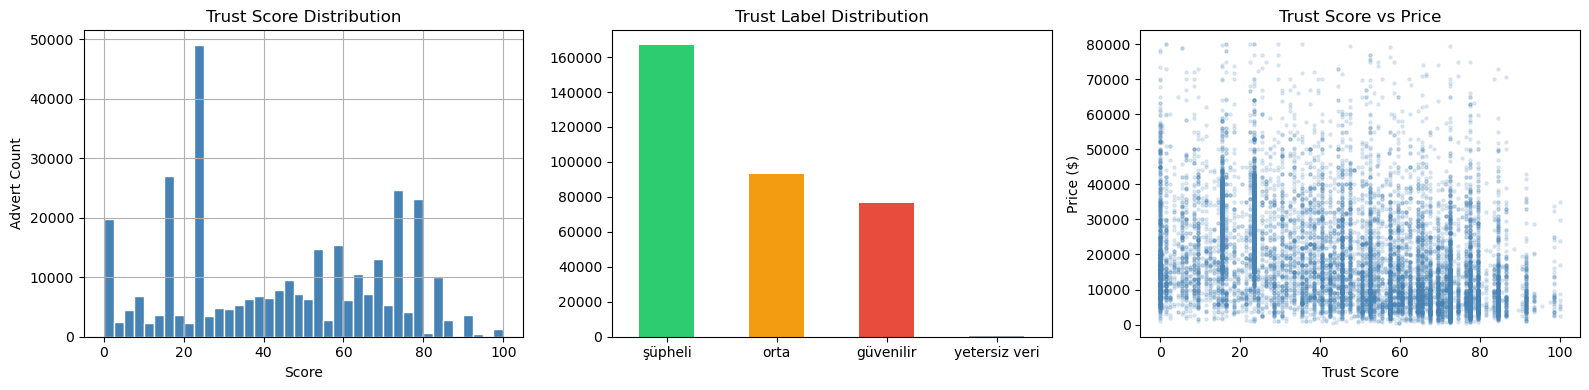

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Trust score distribution
df["trust_score"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Trust Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Advert Count")

# 2) Label distribution
df["trust_label"].value_counts().plot(
    kind="bar", ax=axes[1],
    color=["#2ecc71", "#f39c12", "#e74c3c", "#95a5a6"]
)
axes[1].set_title("Trust Label Distribution")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

# 3) Trust score vs price scatter
sample = df[["trust_score", "price"]].dropna().sample(
    min(15000, len(df)), random_state=42
)
axes[2].scatter(sample["trust_score"], sample["price"],
                alpha=0.15, s=5, color="steelblue")
axes[2].set_title("Trust Score vs Price")
axes[2].set_xlabel("Trust Score")
axes[2].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

In [74]:
# Feature list for the model

# Categorical encode
from sklearn.preprocessing import LabelEncoder

cat_cols = ["manufacturer", "model", "condition",
            "fuel", "title_status", "transmission", "type"]

le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        df[f"{col}_enc"] = le.fit_transform(df[col].astype(str))

df["vehicle_age"] = 2024 - df["year"]

# Final feature list
BASE_FEATURES = [
    "vehicle_age",
    "odometer",
    "manufacturer_enc",
    "model_enc",
    "condition_enc",
    "fuel_enc",
    "title_status_enc",
    "transmission_enc",
    "type_enc",
]

NLP_FEATURES = [
    "trust_score",       
    "is_dealer",         
    "honest_hits",
    "suspicious_hits",
    "stuffing_score",
    "desc_word_count",
]

FEATURE_COLS = BASE_FEATURES + NLP_FEATURES + tfidf_cols

In [75]:
dealer_keywords = [
    "stop by", "visit us", "our dealership", "our inventory",
    "sales tax", "doc fee", "documentation fee", "dealer",
    "financing available", "trade-in", "trade in",
    "call us today", "call or text us"
]

def is_dealer(text: str) -> int:
    if not isinstance(text, str):
        return 0
    text = text.lower()
    hits = sum(1 for k in dealer_keywords if k in text)
    return int(hits >= 2)

df["is_dealer"] = df["desc_trust_clean"].apply(is_dealer)
print("is_dealer eklendi:", df["is_dealer"].value_counts().to_dict())

# FEATURE_COLS tanımla
BASE_FEATURES = [
    "vehicle_age", "odometer",
    "manufacturer_enc", "model_enc", "condition_enc",
    "fuel_enc", "title_status_enc", "transmission_enc", "type_enc",
]

NLP_FEATURES = [
    "trust_score", "is_dealer", "honest_hits",
    "suspicious_hits", "stuffing_score", "desc_word_count",
]

tfidf_cols = [f"tfidf_{i}" for i in range(80)]

FEATURE_COLS = BASE_FEATURES + NLP_FEATURES + tfidf_cols

is_dealer eklendi: {0: 169356, 1: 167462}


In [76]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[FEATURE_COLS].fillna(0)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

preds = model.predict(X_test)
print(f"\nMAE : ${mean_absolute_error(y_test, preds):,.0f}")
print(f"R²  : {r2_score(y_test, preds):.3f}")

[0]	validation_0-rmse:13395.55290
[50]	validation_0-rmse:6736.41979
[100]	validation_0-rmse:5755.21807
[150]	validation_0-rmse:5295.04558
[200]	validation_0-rmse:5008.46794
[250]	validation_0-rmse:4787.89829
[299]	validation_0-rmse:4626.66372

MAE : $3,034
R²  : 0.888


=== Top 20 Feature ===
         feature  importance
     vehicle_age    0.140512
        fuel_enc    0.116864
        tfidf_15    0.070574
         tfidf_0    0.041239
        tfidf_42    0.040844
        odometer    0.036926
         tfidf_8    0.029837
        tfidf_62    0.027457
        tfidf_74    0.026902
        tfidf_18    0.025625
        tfidf_37    0.023521
title_status_enc    0.018042
        type_enc    0.017629
manufacturer_enc    0.013758
         tfidf_4    0.013418
         tfidf_3    0.013100
        tfidf_49    0.012797
       model_enc    0.012186
 desc_word_count    0.012060
        tfidf_66    0.010757


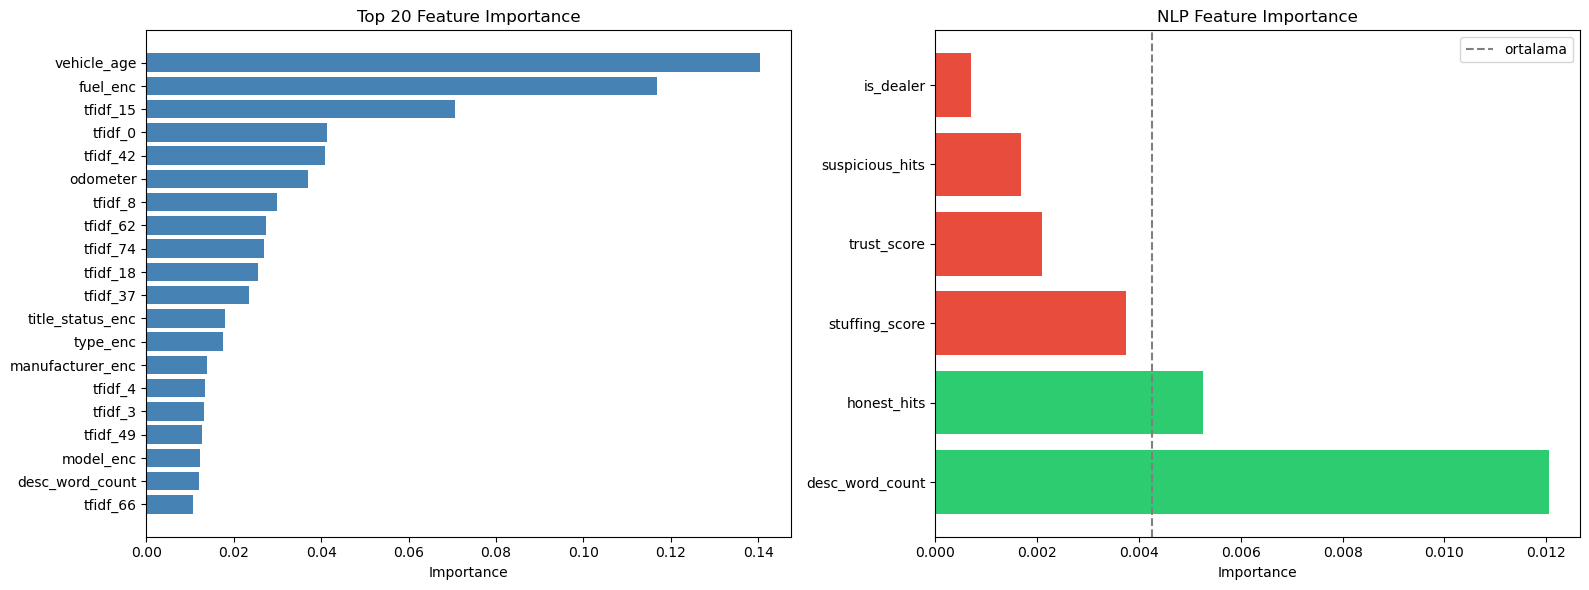

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("=== Top 20 Feature ===")
print(importance_df.head(20).to_string(index=False))

# visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# top 20
top20 = importance_df.head(20)
axes[0].barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
axes[0].set_title("Top 20 Feature Importance")
axes[0].set_xlabel("Importance")

# Only NLP features
nlp_importance = importance_df[importance_df["feature"].isin(NLP_FEATURES)]
colors = ["#2ecc71" if v > nlp_importance["importance"].mean() 
          else "#e74c3c" for v in nlp_importance["importance"]]
axes[1].barh(nlp_importance["feature"], nlp_importance["importance"], color=colors)
axes[1].set_title("NLP Feature Importance")
axes[1].set_xlabel("Importance")
axes[1].axvline(nlp_importance["importance"].mean(), 
                color="gray", linestyle="--", label="ortalama")
axes[1].legend()

plt.tight_layout()
plt.show()

In [78]:
# order of NLP features
nlp_importance = importance_df[importance_df["feature"].isin(NLP_FEATURES)].copy()
print("Order of NLP Features")
print(nlp_importance.to_string(index=False))
print()

# General Order
for feat in NLP_FEATURES:
    rank = importance_df.reset_index(drop=True)
    rank = rank[rank["feature"] == feat].index[0] + 1
    imp = importance_df[importance_df["feature"] == feat]["importance"].values[0]
    print(f"{feat:20s} → sıra: {rank:3d} / {len(FEATURE_COLS)}  |  importance: {imp:.5f}")
print()

# Sum of TF-IDF Features vs. Others
tfidf_total = importance_df[importance_df["feature"].str.startswith("tfidf")]["importance"].sum()
base_total  = importance_df[importance_df["feature"].isin(BASE_FEATURES)]["importance"].sum()
nlp_total   = importance_df[importance_df["feature"].isin(NLP_FEATURES)]["importance"].sum()

print("Group-based total importance")
print(f"Basic Features  : {base_total:.3f}  ({base_total*100:.1f}%)")
print(f"NLP features   : {nlp_total:.3f}  ({nlp_total*100:.1f}%)")
print(f"TF-IDF features: {tfidf_total:.3f}  ({tfidf_total*100:.1f}%)")

Order of NLP Features
        feature  importance
desc_word_count    0.012060
    honest_hits    0.005259
 stuffing_score    0.003738
    trust_score    0.002094
suspicious_hits    0.001689
      is_dealer    0.000694

trust_score          → sıra:  83 / 95  |  importance: 0.00209
is_dealer            → sıra:  95 / 95  |  importance: 0.00069
honest_hits          → sıra:  39 / 95  |  importance: 0.00526
suspicious_hits      → sıra:  92 / 95  |  importance: 0.00169
stuffing_score       → sıra:  52 / 95  |  importance: 0.00374
desc_word_count      → sıra:  19 / 95  |  importance: 0.01206

Group-based total importance
Basic Features  : 0.365  (36.5%)
NLP features   : 0.026  (2.6%)
TF-IDF features: 0.610  (61.0%)


`trust_score` received a low importance score in price prediction because TF-IDF extracts the same information from the description in a richer manner. However, the true value of `trust_score` lies not in price prediction, but in the fairness score—specifically, in answering the user's question: "Is this listing trustworthy?"

In [84]:
#Measuring the trust score
def justice_score(actual_price, predicted_price, trust_score):
    deviation = (actual_price - predicted_price) / predicted_price

    price_component = max(0, 100 - abs(deviation) * 150)
    trust_component = trust_score
    final = price_component * 0.6 + trust_component * 0.4

    if deviation > 0.15:
        verdict = f"Expensive. price is %{deviation*100:.0f} higher than the market. "
    elif deviation < -0.15:
        verdict = "Cheap"
    else:
        verdict = "Fair Price"

    return {
        "justice_score":  round(final, 1),
        "verdict":        verdict,
        "fair_price_est": round(predicted_price, -2),
        "deviation_pct":  round(deviation * 100, 1),
    }
test_df = df.loc[X_test.index].copy()
test_df["predicted_price"] = preds.tolist()

test_df["justice"] = test_df.apply(
    lambda row: justice_score(
        row["price"],
        row["predicted_price"],
        row["trust_score"]
    ), axis=1
)

justice_expanded = pd.DataFrame(test_df["justice"].tolist(), index=test_df.index)
test_df = pd.concat([test_df, justice_expanded], axis=1)

print("Verdict Distribution" )
print(test_df["verdict"].str.split("—").str[0].str.strip().value_counts())
print()
print("Justice score statistics")
print(test_df["justice_score"].describe().round(1))
print()

cols = ["price", "predicted_price", "fair_price_est",
        "deviation_pct", "trust_score", "justice_score", "verdict"]

Verdict Distribution
verdict
Fair Price                                          36698
Cheap                                               16900
Expensive. price is %16 higher than the market.       678
Expensive. price is %17 higher than the market.       635
Expensive. price is %19 higher than the market.       617
                                                    ...  
Expensive. price is %293 higher than the market.        1
Expensive. price is %549 higher than the market.        1
Expensive. price is %553 higher than the market.        1
Expensive. price is %196 higher than the market.        1
Expensive. price is %322 higher than the market.        1
Name: count, Length: 250, dtype: int64

Justice score statistics
count    67364.0
mean        61.3
std         15.9
min          0.0
25%         52.9
50%         62.7
75%         72.0
max         99.8
Name: justice_score, dtype: float64



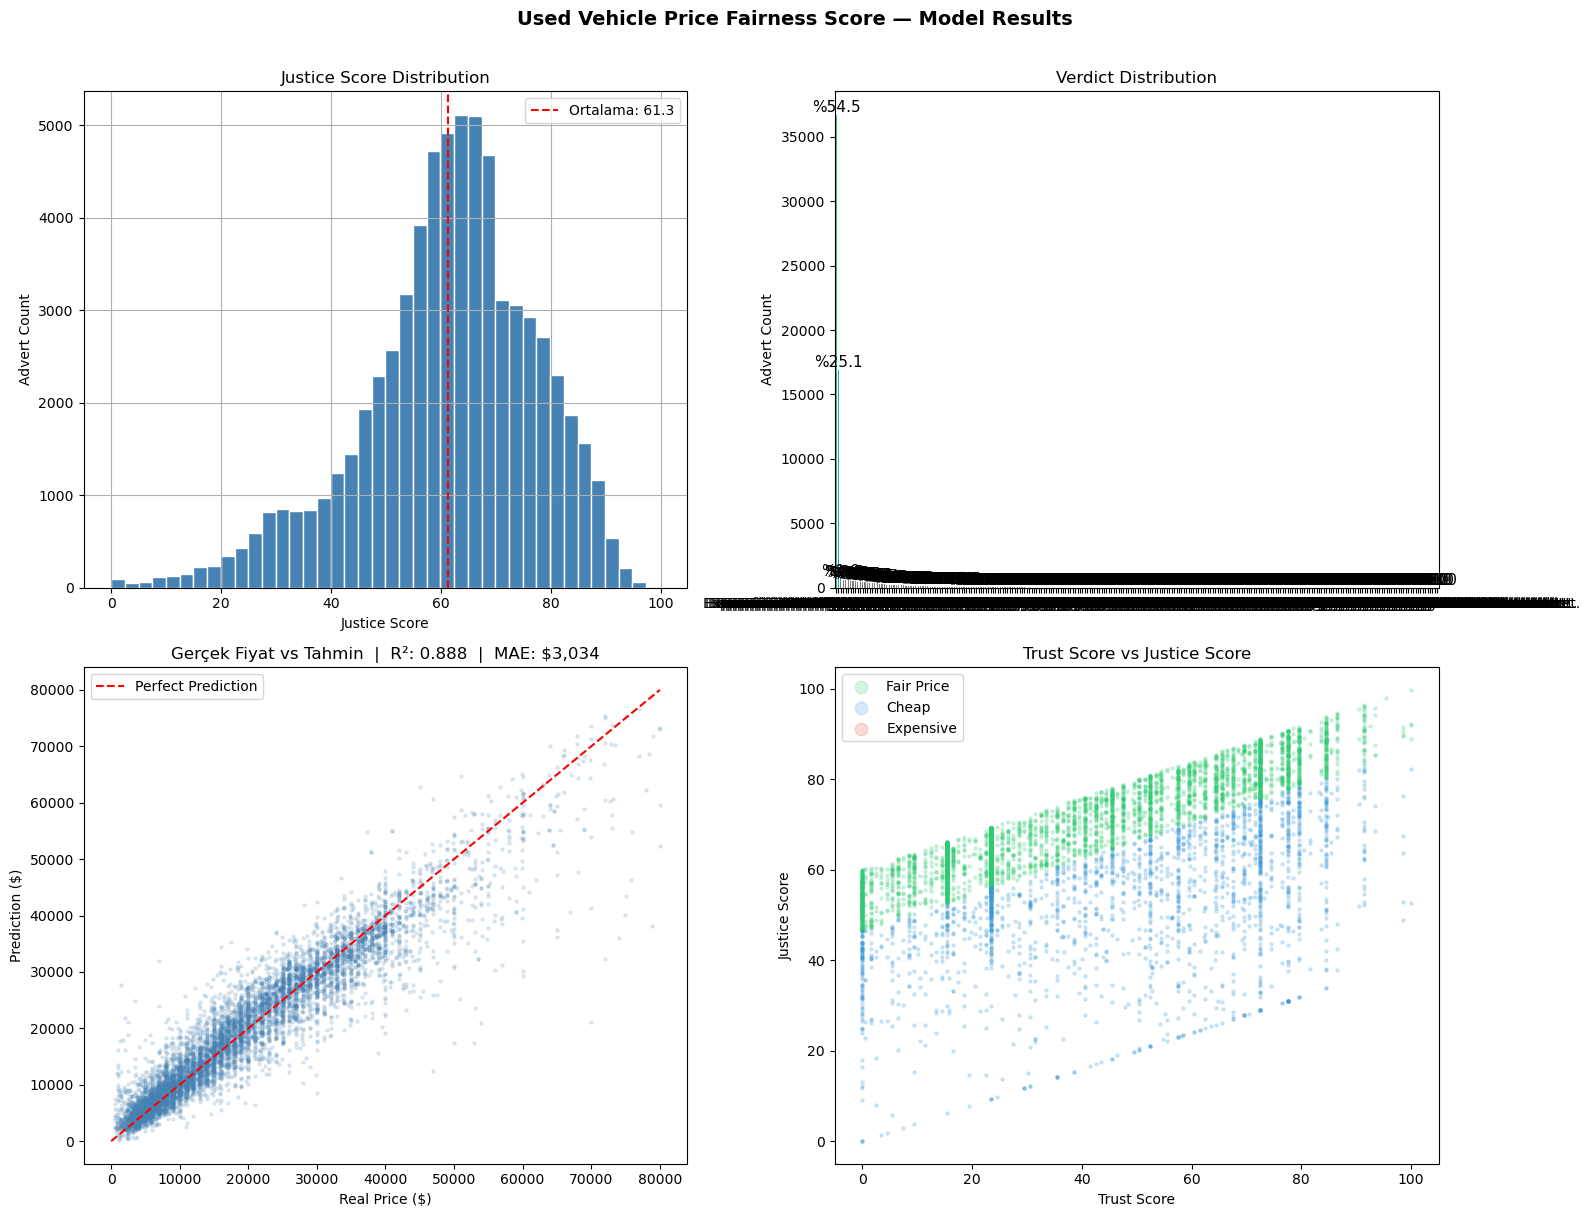

In [80]:
#Visualizations

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Justice score distribution
test_df["justice_score"].hist(bins=40, ax=axes[0,0], color="steelblue", edgecolor="white")
axes[0,0].axvline(test_df["justice_score"].mean(), color="red", linestyle="--", label=f"Ortalama: {test_df['justice_score'].mean():.1f}")
axes[0,0].set_title("Justice Score Distribution")
axes[0,0].set_xlabel("Justice Score")
axes[0,0].set_ylabel("Advert Count")
axes[0,0].legend()

# 2) Verdict distribution
verdict_counts = test_df["verdict"].str.split("—").str[0].str.strip().value_counts()
colors = {"Fair Price": "#2ecc71", "Cheap": "#3498db", "Expensive": "#e74c3c"}
verdict_counts.plot(
    kind="bar", ax=axes[0,1],
    color=[colors.get(v, "gray") for v in verdict_counts.index]
)
axes[0,1].set_title("Verdict Distribution")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Advert Count")
axes[0,1].tick_params(axis="x", rotation=0)
for i, v in enumerate(verdict_counts):
    axes[0,1].text(i, v + 200, f"%{v/len(test_df)*100:.1f}", ha="center", fontsize=11)

# 3) Gerçek fiyat vs tahmin
sample = test_df[["price", "predicted_price"]].dropna().sample(8000, random_state=42)
axes[1,0].scatter(sample["price"], sample["predicted_price"],
                  alpha=0.15, s=5, color="steelblue")
max_val = max(sample["price"].max(), sample["predicted_price"].max())
axes[1,0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect Prediction")
axes[1,0].set_title(f"Gerçek Fiyat vs Tahmin  |  R²: {r2_score(y_test, preds):.3f}  |  MAE: ${mean_absolute_error(y_test, preds):,.0f}")
axes[1,0].set_xlabel("Real Price ($)")
axes[1,0].set_ylabel("Prediction ($)")
axes[1,0].legend()

# 4) Trust score vs Justice score
sample2 = test_df[["trust_score", "justice_score", "verdict"]].dropna().sample(8000, random_state=42)
verdict_simple = sample2["verdict"].str.split("—").str[0].str.strip()
color_map = {"Fair Price": "#2ecc71", "Cheap": "#3498db", "Expensive": "#e74c3c"}
for verdict_type, color in color_map.items():
    mask = verdict_simple == verdict_type
    axes[1,1].scatter(
        sample2.loc[mask, "trust_score"],
        sample2.loc[mask, "justice_score"],
        alpha=0.2, s=5, color=color, label=verdict_type
    )
axes[1,1].set_title("Trust Score vs Justice Score")
axes[1,1].set_xlabel("Trust Score")
axes[1,1].set_ylabel("Justice Score")
axes[1,1].legend(markerscale=4)

plt.suptitle("Used Vehicle Price Fairness Score — Model Results", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()